# In-Memory Checkpointing [Step 1 - MemorySaver Basics]

> **MLCourse - Agentic AI - LangGraph**

This notebook demonstrates how to use `MemorySaver` to persist conversation
state across multiple turns. We build a simple chatbot that remembers previous
messages within a thread using LangGraph's built-in checkpointing.

In [1]:
import os
from dotenv import load_dotenv
# load .env from the agentic ai directory
load_dotenv("D:/projects/python/MLCourse/03_agentic_ai/.env")

False

In [2]:
# Check for required API keys - guard cell that shows status
groq_key = os.environ.get("GROQ_API_KEY", "")
if groq_key:
    print("GROQ_API_KEY found")
else:
    print("GROQ_API_KEY not set - using ChatOllama (local, no key needed)")

GROQ_API_KEY not set - using ChatOllama (local, no key needed)


In [3]:
# Core imports for LangGraph persistence
from typing import TypedDict, Annotated
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver
from langchain_ollama import ChatOllama

In [4]:
# Define the state schema for our chatbot
# Messages list accumulates via list append (add_messages reducer)
class ChatState(TypedDict):
    messages: Annotated[list, add_messages]

In [5]:
# Initialize a lightweight local LLM via Ollama
# No API key required - runs entirely on your machine
llm = ChatOllama(model="llama3.1:8b", temperature=0)

In [6]:
# Define the chatbot node that calls the LLM
# This function receives full state and returns a message update
def chatbot(state: ChatState):
    response = llm.invoke(state["messages"])
    return {"messages": [response]}

In [7]:
# Build a minimal graph: start -> chatbot -> end
graph_builder = StateGraph(ChatState)
graph_builder.add_node("chatbot", chatbot)
graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("chatbot", END)

In [8]:
# Create MemorySaver - holds all checkpoints in RAM
# Each checkpoint stores the full state at that point
checkpointer = MemorySaver()

In [9]:
# Compile graph with checkpointer attached
# The checkpointer enables persistence via thread_id
graph = graph_builder.compile(checkpointer=checkpointer)

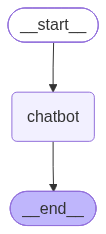

In [10]:
# Visualize the graph structure
from IPython.display import Image, display
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Graph visualization unavailable: {e}")
    print("Graph nodes: START -> chatbot -> END")

In [11]:
# Thread config acts as a unique conversation identifier
# Different thread_ids maintain completely separate conversations
config_thread_1 = {"configurable": {"thread_id": "thread-1"}}
config_thread_2 = {"configurable": {"thread_id": "thread-2"}}

In [12]:
# Send first message to thread-1
# The checkpointer stores the initial state as checkpoint-1
response = graph.invoke(
    {"messages": [("user", "Hi, my name is Alice.")]},
    config=config_thread_1,
)
print("Thread 1 - Turn 1:")
print(response["messages"][-1].content)

Thread 1 - Turn 1:
Hello Alice! It's nice to meet you. Is there something I can help you with or would you like to chat?


In [13]:
# Send second message to thread-1
# The checkpointer loads previous state so the LLM sees full history
response = graph.invoke(
    {"messages": [("user", "What was my name again?")]},
    config=config_thread_1,
)
print("Thread 1 - Turn 2:")
print(response["messages"][-1].content)

Thread 1 - Turn 2:
Your name is Alice.


In [14]:
# Send first message to thread-2 - completely separate conversation
# The LLM has no knowledge of thread-1's messages
response = graph.invoke(
    {"messages": [("user", "Hi, my name is Bob.")]},
    config=config_thread_2,
)
print("Thread 2 - Turn 1:")
print(response["messages"][-1].content)

Thread 2 - Turn 1:
Nice to meet you, Bob! Is there something I can help you with or would you like to chat for a bit?


In [15]:
# Confirm thread isolation - thread-2 does not know about Alice
response = graph.invoke(
    {"messages": [("user", "What is my name?")]},
    config=config_thread_2,
)
print("Thread 2 - Turn 2:")
print(response["messages"][-1].content)

Thread 2 - Turn 2:
Your name is Bob! We just established that earlier. How's your day going so far, Bob?


In [16]:
# Inspect the checkpoint structure
# list returns all checkpoints for a given thread
checkpoints = list(graph.get_state_history(config_thread_1))
print(f"Thread 1 has {len(checkpoints)} checkpoints:")
for i, cp in enumerate(checkpoints):
    msg_count = len(cp.values.get("messages", []))
    print(f"  Checkpoint {i}: {cp.config['configurable']['checkpoint_id'][:8]}... ({msg_count} messages)")

Thread 1 has 6 checkpoints:
  Checkpoint 0: 1f1a17a9... (4 messages)
  Checkpoint 1: 1f1a17a9... (3 messages)
  Checkpoint 2: 1f1a17a9... (2 messages)
  Checkpoint 3: 1f1a17a9... (2 messages)
  Checkpoint 4: 1f1a17a9... (1 messages)
  Checkpoint 5: 1f1a17a9... (0 messages)


In [17]:
# The latest checkpoint holds the full conversation state
latest = graph.get_state(config_thread_1)
print("\nLatest checkpoint messages:")
for msg in latest.values["messages"]:
    role = msg.type
    content = msg.content[:80] + "..." if len(msg.content) > 80 else msg.content
    print(f"  [{role}] {content}")


Latest checkpoint messages:
  [human] Hi, my name is Alice.
  [ai] Hello Alice! It's nice to meet you. Is there something I can help you with or wo...
  [human] What was my name again?
  [ai] Your name is Alice.


In [18]:
# Verify persistence - continue thread-1 after inspecting checkpoints
# The conversation memory is fully preserved
response = graph.invoke(
    {"messages": [("user", "Summarize our conversation in one sentence.")]},
    config=config_thread_1,
)
print("Thread 1 - Turn 3:")
print(response["messages"][-1].content)

print("\nPersistence summary:")
print("  MemorySaver stores checkpoints in RAM per thread_id")
print("  Each thread maintains independent conversation history")
print("  Checkpoints are lost when the process exits")

Thread 1 - Turn 3:
We've had a brief introduction, where I learned your name is Alice and we exchanged a few pleasantries.

Persistence summary:
  MemorySaver stores checkpoints in RAM per thread_id
  Each thread maintains independent conversation history
  Checkpoints are lost when the process exits
